In [1]:
from afm_lib.graphs.grid_search import build_grid_search_graph
from afm_lib.schemas.recipe import load_recipe, site_program

from IPython.display import Image


In [2]:
recipe = load_recipe(r"../recipes/alscn_01448_grid.yaml")
graph  = build_grid_search_graph()

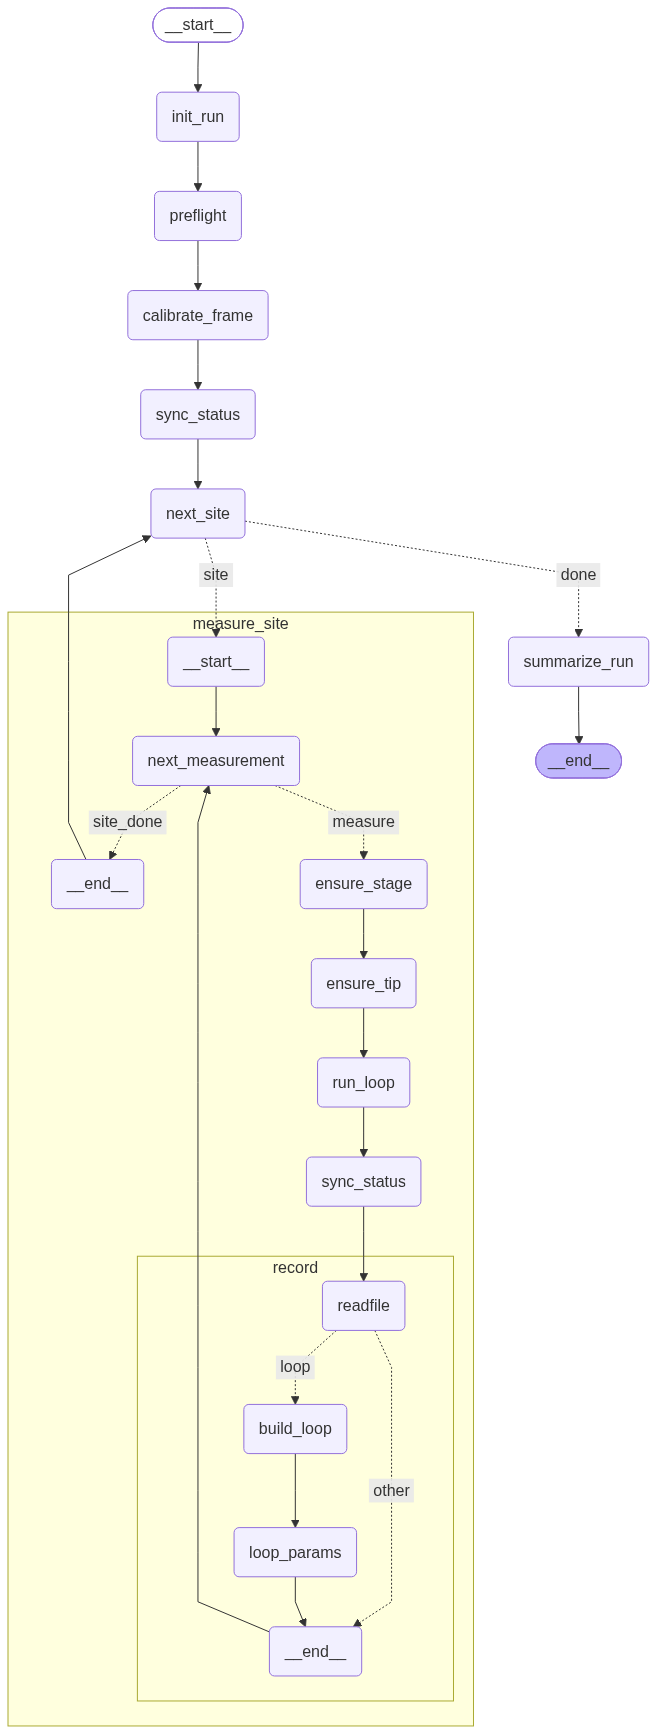

In [3]:

Image(graph.get_graph(xray=True).draw_mermaid_png())

In [4]:
n_meas = len(recipe.sites) * len(site_program(recipe))
cfg = {"recursion_limit": 20 * n_meas + 100}

In [5]:
cfg

{'recursion_limit': 14180}

In [6]:
out = None
async for chunk in graph.astream({"recipe": recipe}, cfg, stream_mode="values"):
    out = chunk

[init_run] alscn_01448: 88 sites x 8 points = 704 loops -> C:\Users\Asylum User\Documents\GitHub\AFM_Combinatorial_Libraries\runs\20260901_171601_alscn_01448
[preflight] stage (-18.980, +21.391) mm | dir 'C:\\Users\\Asylum User\\Documents\\Asylum Research Data\\260831' | feedback False | frame 24.2 um @ 256 px | f_DART 381.7 kHz | V_ac 0.5 V
[calibrate] offset (+5.095, +35.651) um | sens 9.2640e-06 / 9.9032e-06 m/V
[next_site] 1/88  r0c00 -> (+21.064, +20.813) mm
[next_measurement] r0c00 1/8: loop at (-1.000, -1.000) um from centre -> (-1.000, -1.000) um | 20.0 V, 3 cycles
[ensure_stage] (-18.980, +21.391) -> (+21.064, +20.813) mm
[ensure_stage] WARNING: approach did not report contact — Stage moved to (21.064 mm, 20.813 mm). Approach did not establish contact.
[ensure_stage] Stage moved to (21.064 mm, 20.813 mm). Approach did not establish contact.
[ensure_tip] (+0.0000, +0.0000) -> (-1.0000, -1.0000) um
[ensure_tip] achieved (-1.0000, -1.0000) um, error 0.0 nm
[run_loop] v_dc_max 20.

In [14]:
import numpy as np
from pathlib import Path
from afm_lib.utils.loops_utils import _monotone_segments

d = Path(r"..\runs\20260831_170759_plzt_grid\loops\site00_step0_pt00")
bias = np.load(d / "bias_off.npy")          # check the actual filename in that folder

segs = _monotone_segments(bias)
print("bias range:", bias.min(), "..", bias.max())
print("segments:", [(s.start, s.stop, k) for s, k in segs])
print("rising:", sum(k == "rising" for _, k in segs),
      " falling:", sum(k == "falling" for _, k in segs))

bias range: -19.951923 .. 19.759615
segments: [(16, 50, 'falling'), (49, 83, 'rising'), (82, 116, 'falling'), (115, 150, 'rising'), (149, 183, 'falling')]
rising: 2  falling: 3
